This is a jupyter notebook for Jonathan's experiments. I am so bad at coding lol...

Below is a class of the lorenz1963 chaotic function. 

In [2]:
import numpy as np

class lorenz1963:
    def __init__(self, rho, beta, sigma, numTimeSteps, initialCondition) -> None:
        self.rho = rho
        self.beta  = beta
        self.sigma = sigma
        self.numTimeSteps = numTimeSteps
        self.states = np.zeros((numTimeSteps, 3))
        self.states[0, :] = initialCondition
        self.tstep = 0
        
    
    def statesDot(self, time, currState) -> np.array:
        
        dx_dt = self.sigma*(currState[1] - currState[0])
        dy_dt = currState[0]*(self.rho - currState[2]) - currState[1]
        dz_dt = currState[0]*currState[1] - self.beta*currState[2]

        states_dt = np.array([dx_dt, dy_dt, dz_dt])
        return states_dt
    
    def getCurrState(self) -> np.array:
        return self.states[self.tstep, :]

    def setState(self, nextState) -> None:
        self.tstep = self.tstep + 1
        self.states[self.tstep, :] = nextState
        





Testing Lorenz1963 chaotic class made above. This will also be used as the test case for the rk4 integrator.

In [3]:
testCase = lorenz1963(28, 8/3, 10, 10000, np.array([1, 2, 3]))
testCase.statesDot(0, np.array([1, 2, 3]))

array([10., 23., -6.])

below is a first pass at an RK4 integrator. I don't love it but I prove below that it works

In [4]:
def f2(currState, deltaT, currTime, f1) -> np.array:
    f2Output = f1(currTime, currState + deltaT/2*f1(currTime, currState))
    return f2Output

def f3(currState, deltaT, currTime, f1, f2) -> np.array:
    f3Output = f1(currTime, currState + deltaT/2*f2(currState, deltaT, currTime, f1))
    return f3Output

def f4(currState, deltaT, currTime, f1, f2, f3) -> np.array:
    f4Output = f1(currTime, currState + deltaT*f3(currState, deltaT, currTime, f1, f2))
    return f4Output


numTimeSteps = 10000
deltaT = 0.001
totalTime = numTimeSteps*deltaT
initialCondition = np.array([0, 1, 1.05])


lorenzRK4 = lorenz1963(28, 8/3, 10, numTimeSteps+1, initialCondition)

for ctime in np.linspace(0, totalTime, numTimeSteps):
    currTime = ctime
    currState = lorenzRK4.getCurrState()
    f11 = lorenzRK4.statesDot(currTime, currState)
    f22 = f2(currState, deltaT, currTime, lorenzRK4.statesDot)
    f33 = f3(currState, deltaT, currTime, lorenzRK4.statesDot, f2)
    f44 = f4(currState, deltaT, currTime, lorenzRK4.statesDot, f2, f3)
    
    nextState = lorenzRK4.getCurrState() + deltaT/6*(f11 + 2*f22 + 2*f33 + f44)
    lorenzRK4.setState(nextState)

print(lorenzRK4.states)


[[ 0.00000000e+00  1.00000000e+00  1.05000000e+00]
 [ 9.94563126e-03  9.99134725e-01  1.04720870e+00]
 [ 1.97850272e-02  9.98536830e-01  1.04443471e+00]
 ...
 [-6.11222354e+00 -3.61100704e+00  2.76196433e+01]
 [-6.08733012e+00 -3.60987388e+00  2.75680823e+01]
 [-6.06267463e+00 -3.60904474e+00  2.75165634e+01]]


Here is where I do the plotting!

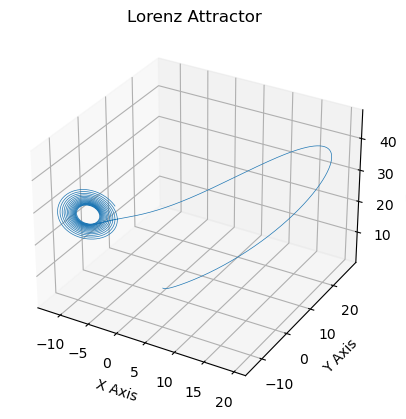

In [5]:
import matplotlib.pyplot as plt

# Plot
ax = plt.figure().add_subplot(projection='3d')

daLorenz = lorenzRK4.states

ax.plot(*lorenzRK4.states.T, lw=0.5)
ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
ax.set_title("Lorenz Attractor")

plt.show()

Now lets check our work by solving it with the scipy rk45 integrator

Text(0.5, 0.92, 'Lorenz Attractor')

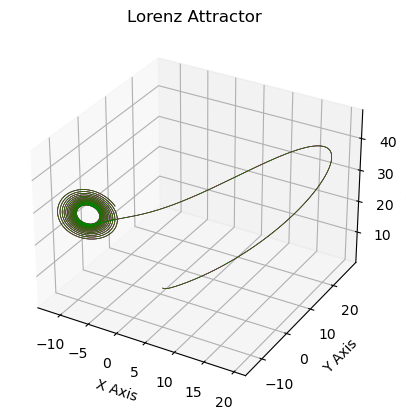

In [6]:
from scipy.integrate import solve_ivp

t = np.linspace(0, totalTime, numTimeSteps)
testCase11 = lorenz1963(28, 8/3, 10, 1000, np.array([1, 2, 3]))
#NOTE I try to set the atol and rtol to fix the integrator to be an RK4 and not an RK45
# not sure if I made a mistake as the algorithms do not exactly align
lorenz_ivp_sol = solve_ivp(testCase11.statesDot, (0, totalTime), initialCondition, method="RK45", t_eval=None, max_step=deltaT, atol=1, rtol=1)
lorenz_ivp_sol1 = solve_ivp(testCase11.statesDot, (0, totalTime), initialCondition, method="RK45", t_eval=None, max_step=deltaT)

ax = plt.figure().add_subplot(projection='3d')
da_sol = lorenz_ivp_sol.y
da_45_sol = lorenz_ivp_sol1.y

ax.plot(*lorenzRK4.states.T, 'b', lw=0.5)
ax.plot(*da_sol, 'r', lw=0.5)
ax.plot(*da_45_sol, 'g', lw=0.5)
ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
ax.set_title("Lorenz Attractor")

Ok Lets try using the classes I now created

In [7]:
print(initialCondition)

[0.   1.   1.05]


In [8]:
from integrators.RK4F import RK4
from components.ComponentF import Component

UUID = 11
numCntrl = 0
initCond = initialCondition
print(initCond)
print(UUID)
print(numCntrl)

[0.   1.   1.05]
11
0


In [10]:
aa = Component(1, 0, np.array([0, 1, 1.05]))
print(aa.getCurrCntrl())
print(aa.getCurrState())
print(aa.UUID)
print(aa.numCntrl)


[]
[0.   1.   1.05]
1
0


In [18]:

newLorenz = Component(UUID, numCntrl, initCond)

rk4 = RK4()

time = np.arange(0, 10, 0.001)
States = np.zeros((time.size, initCond.size))
States[0, :] = initCond

for ii in np.arange(time.size-1):
    currTime = time[ii]
    nextState = rk4.getNextState(newLorenz, currTime, 0.001)
    newLorenz.setCurrState(nextState)
    States[ii+1, :] = nextState





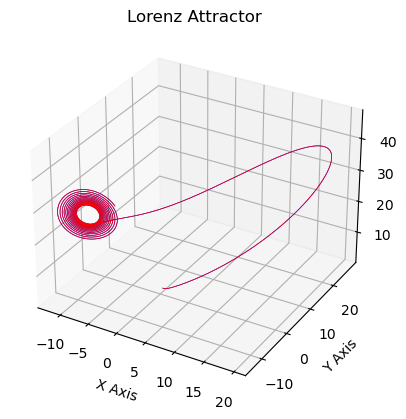

In [19]:
ax = plt.figure().add_subplot(projection='3d')

daLorenz = lorenzRK4.states

ax.plot(*lorenzRK4.states.T, 'b', lw=0.5)
ax.plot(*States.T, 'r', lw=0.5)
ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
ax.set_title("Lorenz Attractor")

plt.show()